# Testing libraries

In [2]:
!pip3 install pyswisseph


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [3]:
import swisseph as swe

swe.set_sid_mode(swe.SIDM_LAHIRI)
jd = swe.julday(2016, 6, 15)
coords = (41.39858935189999, 2.1853450576007365, 18)
coords = (1000, 10000, 0)
swe.set_topo(*coords) # ESMUC
xx, ret = swe.calc_ut(jd, swe.MOON)
xx # longitude, latitude, distance (AU), Speed in longitude (deg/day), Speed in latitude (deg/day), Speed in distance (AU/day)

(209.35861593967851,
 3.415933843983159,
 0.00270763893845504,
 11.826660146350678,
 0.7636622663684645,
 -3.693784163308116e-08)

In [4]:
!pip3 install ephem


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip



https://rhodesmill.org/pyephem/quick
https://rhodesmill.org/pyephem/radec
https://rhodesmill.org/pyephem/tutorial.html

In [5]:
def pretty(d, indent=0):
   for key, value in d.items():
      print('\t' * indent + str(key))
      if isinstance(value, dict):
         pretty(value, indent+1)
      else:
         print('\t' * (indent+1) + str(value))

In [289]:
import ephem
from zoneinfo import ZoneInfo

planets = [
    ephem.Moon(),
    ephem.Mercury(),
    ephem.Venus(),
    ephem.Mars(),
    ephem.Jupiter(),
    ephem.Saturn(),
    ephem.Uranus()
]

valsTemplate = {'ra': '', 'dec': '', 'mag': '', 'size': '', 'separation': ''}

measurings = dict.fromkeys((planet.name for planet in planets), {})


observer = ephem.Observer()
observer.name = "ESMUC"
observer.lon = '41.39858935189999'
observer.lat = '2.1853450576007365'
observer.elevation = 18  # meters

zone = ZoneInfo('Europe/Madrid')
d = ephem.Date('2016/06/17 00:00')
local = ephem.to_timezone(d, zone)

print(d, local)

observer.date = local
rangDies = 1
stepHores = 1
resolucio = 22
resolucio = 24 - resolucio
print(int(rangDies * (24/resolucio)))

for i in range(int(rangDies * (24/resolucio))):
    for j, planet in enumerate(planets):
        planet.compute(observer)
        dateValues = dict({str(observer.date):{'ra': planet.ra, 'dec': planet.dec, 'mag': planet.mag, 'size': planet.size, 'separation': ephem.separation(observer, planet), 'alt': planet.alt, 'az': planet.az}})
        measurings[planet.name] =  {**measurings[planet.name], **dateValues}

        if(planet.name == "Moon"):
            print('%s %s %s' % (observer.date, ephem.Moon(observer).az, ephem.Moon(observer).alt))    

        # print('%s measured from %s:' % (planet.name, observer.name))
        # print('%s, %s. Magnitude: %s, Size: %s' % (planet.ra, planet.dec, planet.mag, planet.size)) # Right Ascension, Declination (Apparent Topocentric Position, aka des del punt d'observació), magnitude
        # print(ephem.separation(observer, planet))
    observer.date += stepHores * ephem.hour

# pretty((measurings))


2016/6/17 00:00:00 2016-06-17 02:00:00+02:00
12
2016/6/17 00:00:00 256:46:44.6 7:24:32.0
2016/6/17 01:00:00 257:16:56.6 -6:48:57.5
2016/6/17 02:00:00 256:57:51.6 -20:59:48.4
2016/6/17 03:00:00 255:36:39.8 -35:00:34.7
2016/6/17 04:00:00 252:29:46.7 -48:49:56.4
2016/6/17 05:00:00 245:20:50.4 -62:13:32.7
2016/6/17 06:00:00 225:03:15.5 -74:08:34.0
2016/6/17 07:00:00 166:00:47.8 -78:27:31.2
2016/6/17 08:00:00 124:34:40.5 -69:36:23.0
2016/6/17 09:00:00 111:52:22.9 -56:50:15.5
2016/6/17 10:00:00 106:55:08.7 -43:14:55.2
2016/6/17 11:00:00 104:45:20.5 -29:22:41.9


In [287]:
import ephem
from zoneinfo import ZoneInfo

observer = ephem.Observer()
observer.name = "Observation Point"
observer.lat = '41.39858935189999'
observer.lon = '2.1853450576007365'
observer.elevation = 18  # meters
observer.pressure = 0

d = ephem.Date('2016/06/17 00:00')
observer.date = (d)

for _ in range(24):
    moon = ephem.Moon(observer)
    print('%s, az: %s alt: %s' % (observer.date, moon.az, moon.alt))
    observer.date += ephem.hour

2016/6/17 00:00:00, az: 225:14:04.3 alt: 22:39:57.1
2016/6/17 01:00:00, az: 237:11:35.0 alt: 14:01:20.4
2016/6/17 02:00:00, az: 247:39:16.9 alt: 4:14:48.0
2016/6/17 03:00:00, az: 257:12:44.1 alt: -6:13:14.5
2016/6/17 04:00:00, az: 266:28:32.6 alt: -17:02:50.8
2016/6/17 05:00:00, az: 276:07:35.3 alt: -27:56:50.5
2016/6/17 06:00:00, az: 287:04:21.1 alt: -38:36:14.4
2016/6/17 07:00:00, az: 300:43:43.3 alt: -48:32:48.9
2016/6/17 08:00:00, az: 319:19:51.6 alt: -56:54:34.2
2016/6/17 09:00:00, az: 345:03:43.4 alt: -62:05:11.4
2016/6/17 10:00:00, az: 15:06:48.5 alt: -62:10:44.3
2016/6/17 11:00:00, az: 41:03:48.1 alt: -57:09:22.3
2016/6/17 12:00:00, az: 59:52:41.1 alt: -48:54:30.6
2016/6/17 13:00:00, az: 73:41:17.7 alt: -39:04:13.6
2016/6/17 14:00:00, az: 84:45:15.3 alt: -28:31:50.2
2016/6/17 15:00:00, az: 94:30:40.2 alt: -17:46:22.8
2016/6/17 16:00:00, az: 103:52:30.5 alt: -7:07:28.7
2016/6/17 17:00:00, az: 113:31:23.2 alt: 3:07:06.5
2016/6/17 18:00:00, az: 124:02:35.1 alt: 12:36:56.6
2016/6/1

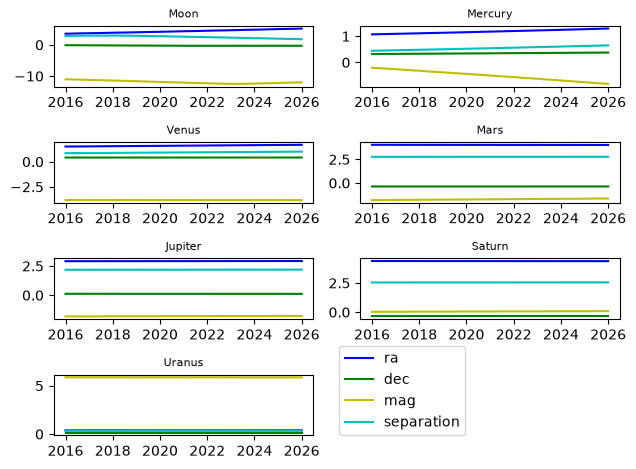

<class 'dict'>


In [146]:
import matplotlib.pylab as plt
import numpy as np

xAxis = np.linspace(2016, 2026, int(rangDies * (24/resolucio))) # TODO: NO FORÇAR EL RANG
planetsArray = {}

for j, planet in enumerate(planets):
    values = {'ra': {}, 'dec': {}, 'mag': {}, 'size': {}, 'separation': {}}

    for i in range(len(measurings[planet.name])):
        values["ra"][i] = list(measurings[planet.name].values())[i]["ra"]
        values["dec"][i] = list(measurings[planet.name].values())[i]["dec"]
        values["mag"][i] = list(measurings[planet.name].values())[i]["mag"]
        values["size"][i] = list(measurings[planet.name].values())[i]["size"]
        values["separation"][i] = list(measurings[planet.name].values())[i]["separation"]

    # pretty(values)

    planetsArray[planet.name] = values

    ax = plt.subplot(4, 2, j+1)
    
    ax.plot(xAxis, values["ra"].values(), 'b', label="ra")
    ax.plot(xAxis, values["dec"].values(), 'g', label="dec")
    ax.plot(xAxis, values["mag"].values(), 'y', label="mag")
    # ax.plot(xAxis, values["size"].values(), 'r', label="size")
    ax.plot(xAxis, values["separation"].values(), 'c', label="separation")
    ax.set_title(planet.name, fontsize=8)


plt.tight_layout()
plt.legend(loc=(1.1,0))
plt.show()

print(type(planetsArray))

# Get planets within viewing scope

Good tool to check if calculations are correct: https://stellarium-web.org/, https://heavens-above.com/

In [ ]:
# Using ephem.separation

coords = (str(observer.lat), str(observer.lon))
coords = ephem.Equatorial(*coords)

viewing_angle = ephem.degrees("180:00:00.0") # String = degrees
print(viewing_angle)

visiblePlanets = {}


for j in range(len(measurings["Moon"])):
    visiblePlanetsAtThisTime = {}
    for i, planet in enumerate(planets):
        thisPlanet = list(measurings[planet.name].values())[j]
        separation = thisPlanet['separation']
        if(separation < viewing_angle):
            time = list(measurings[planet.name].keys())[j]
            # print('%s is visible from %s at %s with %s degrees separation' % (planet.name, observer.name, time, separation))
            visiblePlanetsAtThisTime[planet.name] = {'ra' : thisPlanet['ra'], 'dec': thisPlanet['dec'], 'separation': separation, 'mag': planet.mag, 'size': planet.size}
    # print(visiblePlanetsAtThisTime)
    visiblePlanets[time] = {**visiblePlanetsAtThisTime}

# pretty(visiblePlanets)
pretty((visiblePlanets))


180:00:00.0
2016/6/15 03:00:00
	Moon
		ra
			13:34:57.77
		dec
			-6:41:25.5
		separation
			161:49:57.6
		mag
			-11.02
		size
			1749.7318115234375
	Mercury
		ra
			4:05:57.54
		dec
			18:24:19.1
		separation
			25:30:41.5
		mag
			-0.2
		size
			6.687713623046875
	Venus
		ra
			5:45:32.88
		dec
			23:42:40.0
		separation
			48:30:57.8
		mag
			-3.81
		size
			9.760183334350586
	Mars
		ra
			15:26:31.02
		dec
			-21:03:07.8
		separation
			158:39:40.6
		mag
			-1.81
		size
			17.933897018432617
	Jupiter
		ra
			11:07:23.29
		dec
			6:58:55.1
		separation
			124:47:35.4
		mag
			-1.81
		size
			35.69200897216797
	Saturn
		ra
			16:44:03.71
		dec
			-20:29:11.8
		separation
			145:48:14.6
		mag
			0.03
		size
			18.32777214050293
	Uranus
		ra
			1:28:42.73
		dec
			8:38:44.4
		separation
			20:11:06.9
		mag
			5.87
		size
			3.4487476348876953


In [192]:
# Using ephem.separation

coords = (str(observer.lat), str(observer.lon))
coords = ephem.Equatorial(*coords)

viewing_angle = ephem.degrees("40:00:00.0") # String = degrees
print(viewing_angle)

visiblePlanets = {}


for j in range(len(measurings["Moon"])):
    visiblePlanetsAtThisTime = {}
    for i, planet in enumerate(planets):
        thisPlanet = list(measurings[planet.name].values())[j]
        az = thisPlanet['az']
        alt = thisPlanet['alt']
        if(alt > viewing_angle):
            time = list(measurings[planet.name].keys())[j]
            # print('%s is visible from %s at %s with %s degrees separation' % (planet.name, observer.name, time, separation))
            visiblePlanetsAtThisTime[planet.name] = {'ra' : thisPlanet['ra'], 'dec': thisPlanet['dec'], 'separation': separation, 'mag': planet.mag, 'size': planet.size, 'az': az, 'alt': alt}
    # print(visiblePlanetsAtThisTime)
    visiblePlanets[time] = {**visiblePlanetsAtThisTime}

# pretty(visiblePlanets)
pretty((visiblePlanets))


40:00:00.0
2016/6/15 03:00:00
	Uranus
		ra
			1:28:42.73
		dec
			8:38:44.4
		separation
			20:11:06.9
		mag
			5.87
		size
			3.4487476348876953
		az
			77:15:56.7
		alt
			57:34:30.4


# Fent servir MIDI

In [180]:
import rtmidi
import time as t

midiout = rtmidi.MidiOut()
available_ports = midiout.get_ports()

if available_ports:
    midiout.open_port(0)
else:
    midiout.open_virtual_port("Virtual Output")

print(midiout.get_port_name(0))

with midiout:
    for i, date in enumerate(visiblePlanets):
        planetsVisibleNow = visiblePlanets[date]
        # print(date, planetsVisibleNow)
        notes_on = []
        notes_off = []
        for i, planet in enumerate(planetsVisibleNow):
            planetInfo = planetsVisibleNow[planet]
            note = planetInfo['separation'] * 127
            amplitude = abs(planetInfo['mag'] * 10)
            
            for j, plan in enumerate(planets):
                if planet == plan.name:
                    chan = j
                    break
                else:
                    chan = -1

            NOTE_ON = 0x90
            NOTE_OFF = 0x80
            status_on = NOTE_ON | (chan)
            status_off = NOTE_OFF | (chan)

            note_on = [status_on, note, amplitude]
            notes_on.append(note_on)
            note_off = [status_off, note, amplitude]
            notes_off.append(note_off)

        # print(notes_on, notes_off)
        for message in notes_on:
            midiout.send_message(message)
        t.sleep(.5)
        for message in notes_off:
            midiout.send_message(message)

IAC Driver Bus 1


OverflowError: value too large to convert to unsigned char

# Fent servir OSC

In [ ]:
!pip3 install python-osc


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [ ]:
from pythonosc import udp_client

client = udp_client.SimpleUDPClient("127.0.0.1", 5050, timeout=10)



for i, date in enumerate(visiblePlanets):
        planetsVisibleNow = visiblePlanets[date]

        outMessages = []

        for i, planet in enumerate(planetsVisibleNow):
            planetInfo = planetsVisibleNow[planet]
            print(planetInfo)
            
            for j, plan in enumerate(planets):
                if planet == plan.name:
                    chan = j
                    break
                else:
                    chan = -1

            message = (
                "/"+planet, [
                    planetInfo['ra'],
                    planetInfo['dec'],
                    planetInfo['separation'],
                    planetInfo['mag'],
                    planetInfo['size']
                ]
            )
            outMessages.append(message)

        # print(notes_on, notes_off)
        for message in outMessages:
            print('Sending message', message)
            client.send_message(*message)
        t.sleep(.2)


{'ra': 1.0731982385159204, 'dec': 0.3212334107903869, 'separation': 0.4452603694468723, 'mag': -0.82, 'size': 5.830943584442139}
{'ra': 1.507737426055575, 'dec': 0.4138369781549716, 'separation': 0.8467649631166818, 'mag': -3.82, 'size': 9.789373397827148}
{'ra': 0.3870798608615773, 'dec': 0.15089524377533708, 'separation': 0.35229909487353184, 'mag': 5.86, 'size': 3.467859983444214}
Sending message ('/Mercury', [1.0731982385159204, 0.3212334107903869, 0.4452603694468723, -0.82, 5.830943584442139])
Sending message ('/Venus', [1.507737426055575, 0.4138369781549716, 0.8467649631166818, -3.82, 9.789373397827148])
Sending message ('/Uranus', [0.3870798608615773, 0.15089524377533708, 0.35229909487353184, 5.86, 3.467859983444214])
{'ra': 1.0742745233690068, 'dec': 0.32155516237100995, 'separation': 0.4462687771000324, 'mag': -0.82, 'size': 5.830943584442139}
{'ra': 1.5087119538121012, 'dec': 0.4138899939868514, 'separation': 0.8476240845286519, 'mag': -3.82, 'size': 9.789373397827148}
{'ra':